Basic Setup and Working

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment is ready 🚀")

Environment is ready 🚀


In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

### Generating Sample Data

In [3]:
# Generate hourly timestamps for one week
hours = pd.date_range(start="2026-01-01", periods=168, freq="H")

# Simulate electricity usage (kWh)
np.random.seed(42)
base_usage = np.random.normal(50, 5, 168)  # base consumption

# Simulate evening spikes
for i in range(168):
    if 18 <= hours[i].hour <= 22:  # evening hours
        base_usage[i] += np.random.randint(15, 30)

# Create DataFrame
electricity_data = pd.DataFrame({
    "timestamp": hours,
    "electricity_usage_kwh": base_usage
})

electricity_data.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15152\2073398897.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(start="2026-01-01", periods=168, freq="H")


,timestamp,electricity_usage_kwh
0,2026-01-01 00:00:00,52.483571
1,2026-01-01 01:00:00,49.308678
2,2026-01-01 02:00:00,53.238443
3,2026-01-01 03:00:00,57.615149
4,2026-01-01 04:00:00,48.829233


In [4]:
electricity_data.to_csv("../data/electricity_usage.csv", index=False)

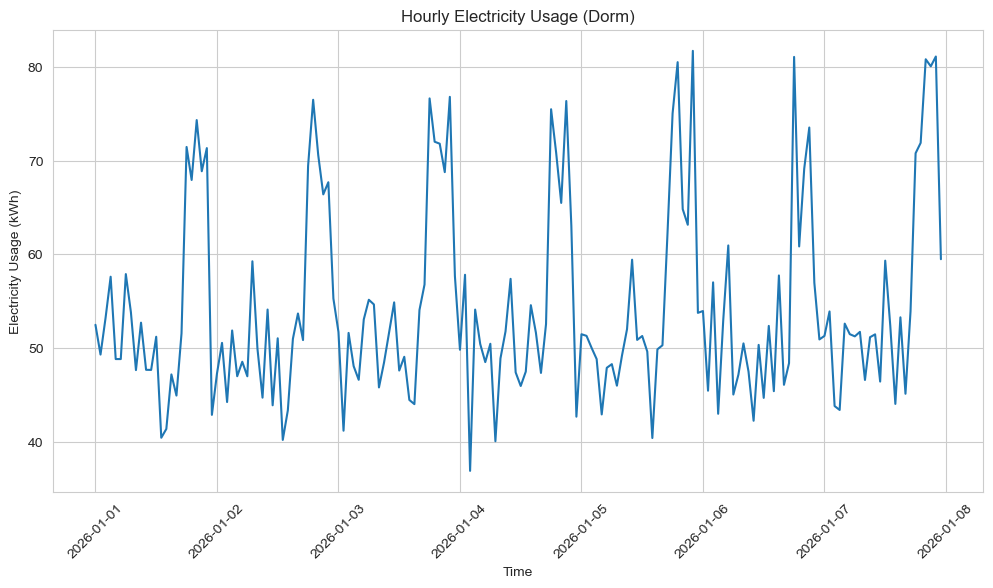

In [5]:
plt.plot(electricity_data["timestamp"], electricity_data["electricity_usage_kwh"])
plt.title("Hourly Electricity Usage (Dorm)")
plt.xlabel("Time")
plt.ylabel("Electricity Usage (kWh)")
plt.xticks(rotation=45)
plt.show()

In [6]:
electricity_data["moving_avg"] = electricity_data["electricity_usage_kwh"].rolling(window=6).mean()

electricity_data.head()

,timestamp,electricity_usage_kwh,moving_avg
0,2026-01-01 00:00:00,52.483571,NaN
1,2026-01-01 01:00:00,49.308678,NaN
2,2026-01-01 02:00:00,53.238443,NaN
3,2026-01-01 03:00:00,57.615149,NaN
4,2026-01-01 04:00:00,48.829233,NaN


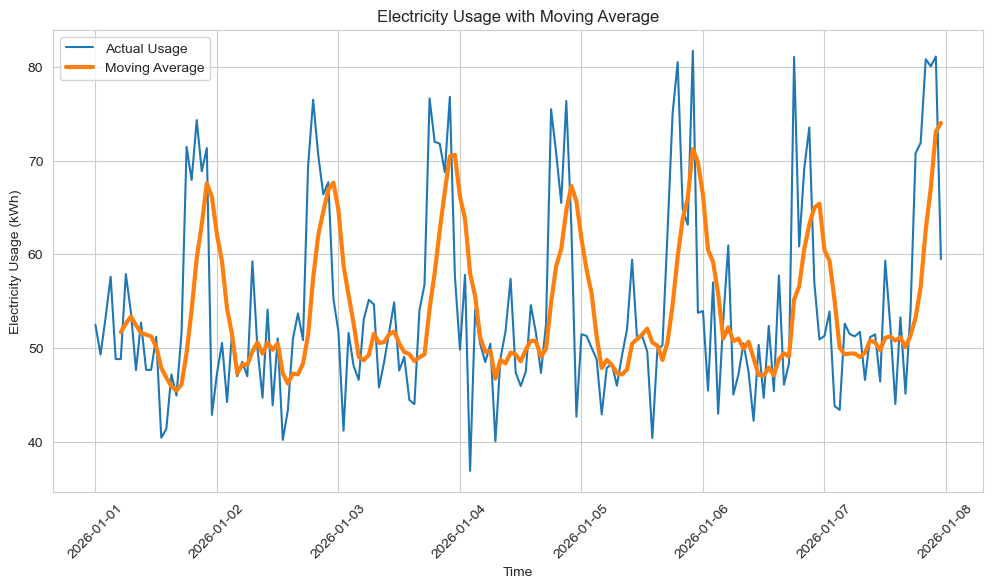

In [7]:
plt.plot(electricity_data["timestamp"], electricity_data["electricity_usage_kwh"], label="Actual Usage")
plt.plot(electricity_data["timestamp"], electricity_data["moving_avg"], label="Moving Average", linewidth=3)

plt.title("Electricity Usage with Moving Average")
plt.xlabel("Time")
plt.ylabel("Electricity Usage (kWh)")
plt.legend()
plt.xticks(rotation=45)

plt.show()

In [8]:
# Extract hour from timestamp
electricity_data["hour"] = electricity_data["timestamp"].dt.hour

electricity_data.head()

,timestamp,electricity_usage_kwh,moving_avg,hour
0,2026-01-01 00:00:00,52.483571,NaN,0
1,2026-01-01 01:00:00,49.308678,NaN,1
2,2026-01-01 02:00:00,53.238443,NaN,2
3,2026-01-01 03:00:00,57.615149,NaN,3
4,2026-01-01 04:00:00,48.829233,NaN,4


In [9]:
from sklearn.linear_model import LinearRegression

# Features and target
X = electricity_data[["hour"]]
y = electricity_data["electricity_usage_kwh"]

# Train model
model = LinearRegression()
model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


In [10]:
electricity_data["predicted_usage"] = model.predict(X)

electricity_data.head()

,timestamp,electricity_usage_kwh,moving_avg,hour,predicted_usage
0,2026-01-01 00:00:00,52.483571,NaN,0,44.888239
1,2026-01-01 01:00:00,49.308678,NaN,1,45.714285
2,2026-01-01 02:00:00,53.238443,NaN,2,46.540331
3,2026-01-01 03:00:00,57.615149,NaN,3,47.366377
4,2026-01-01 04:00:00,48.829233,NaN,4,48.192423


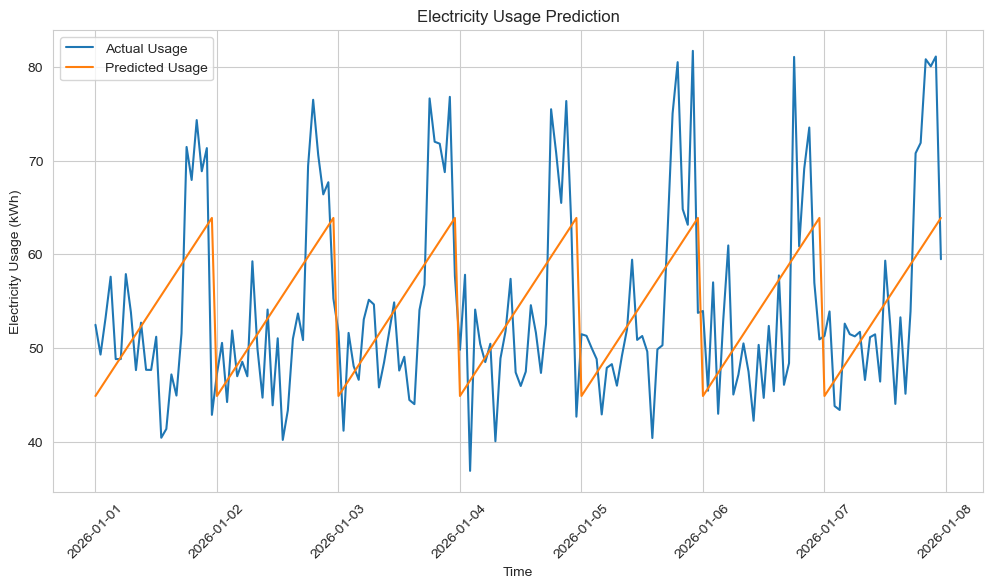

In [11]:
plt.plot(electricity_data["timestamp"], electricity_data["electricity_usage_kwh"], label="Actual Usage")
plt.plot(electricity_data["timestamp"], electricity_data["predicted_usage"], label="Predicted Usage")

plt.title("Electricity Usage Prediction")
plt.xlabel("Time")
plt.ylabel("Electricity Usage (kWh)")
plt.legend()
plt.xticks(rotation=45)

plt.show()

In [12]:
# Define spike threshold
threshold = electricity_data["electricity_usage_kwh"].mean() + 2 * electricity_data["electricity_usage_kwh"].std()

# Create spike column
electricity_data["spike"] = electricity_data["electricity_usage_kwh"] > threshold

electricity_data.head()

,timestamp,electricity_usage_kwh,moving_avg,hour,predicted_usage,spike
0,2026-01-01 00:00:00,52.483571,NaN,0,44.888239,False
1,2026-01-01 01:00:00,49.308678,NaN,1,45.714285,False
2,2026-01-01 02:00:00,53.238443,NaN,2,46.540331,False
3,2026-01-01 03:00:00,57.615149,NaN,3,47.366377,False
4,2026-01-01 04:00:00,48.829233,NaN,4,48.192423,False


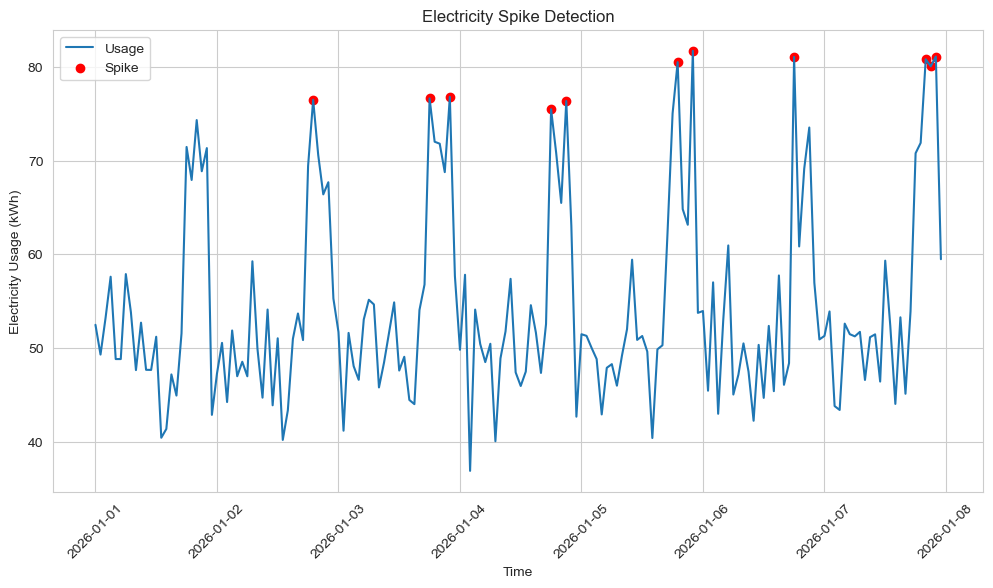

In [13]:
plt.plot(electricity_data["timestamp"], electricity_data["electricity_usage_kwh"], label="Usage")

# Highlight spikes
spikes = electricity_data[electricity_data["spike"]]

plt.scatter(spikes["timestamp"], spikes["electricity_usage_kwh"], color="red", label="Spike")

plt.title("Electricity Spike Detection")
plt.xlabel("Time")
plt.ylabel("Electricity Usage (kWh)")
plt.legend()
plt.xticks(rotation=45)

plt.show()

In [14]:
electricity_data.to_csv("../data/electricity_processed.csv", index=False)